In [1]:
# source-cells: 1
from pathlib import Path
import sys
import numpy as np
import skimage as ski
import matplotlib.pyplot as plt
from matplotlib import patches
from scipy import ndimage as ndi
BOOK = Path('book') if Path('book').is_dir() else Path('.')
sys.path.insert(0, str(BOOK.resolve()))
from _support import image_path, show_images, lab
plt.rcParams['image.cmap'] = 'gray'

def imshow_all(*images, titles=None):
    # Preserve the original comparison's common float-intensity range.
    return show_images(*(ski.util.img_as_float(img) for img in images),
                       titles=titles, shared=True)

source-cells: 2
# 影像濾波、形態學與分割

source-cells: 3
前一章處理像素值、顯示與幾何變換。本章改看鄰近像素的關係：用平均抑制雜訊、以梯度找邊緣，再用形態學整理形狀、分割區域並擷取特徵。

濾波通常重新計算像素值，輸出仍是影像；分割為像素指定標籤，描述子則將外觀整理成數值向量。以下依序使用步階訊號、亮方塊、卡比獸（Snorlax）、硬幣與掃描文字。

濾波函式可查 [SciPy](https://docs.scipy.org/doc/scipy/reference/ndimage.html#filters) 與 [scikit-image](https://scikit-image.org/docs/stable/api/skimage.filters.html)。

source-cells: 4
## 局部濾波

source-cells: 5
局部濾波依鄰近像素計算輸出。Kernel 指定權重，footprint 指定參與運算的鄰居；形態學也常將 footprint 稱為結構元素。先看100點步階訊號，加入平均0、標準差0.35的Gaussian雜訊，使用seed42重現同一組擾動。

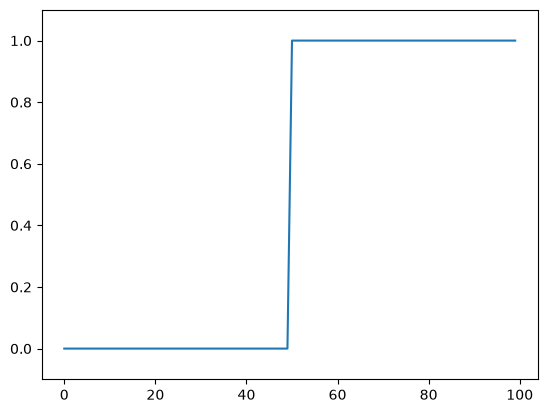

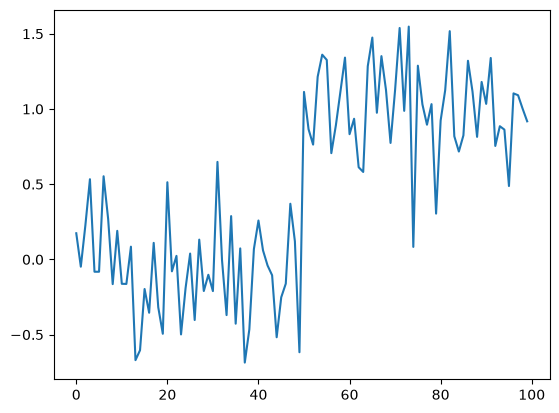

In [2]:
# source-cells: 6
step_signal = np.zeros(100)
step_signal[50:] = 1

fig, ax = plt.subplots()
ax.plot(step_signal)
ax.margins(y=0.1)

# Just to make sure we all see the same results
rng_step = np.random.RandomState(42)

noisy_signal = (step_signal + rng_step.normal(0, 0.35, step_signal.shape))
fig, ax = plt.subplots()
ax.plot(noisy_signal);
plt.show()

source-cells: 7
最簡單的平滑是相鄰兩點平均。鄰域內訊號相近時，正負雜訊會部分抵消；跨過步階的視窗也會混合兩側，使邊界變寬。再改成三點平均，比較平滑程度。

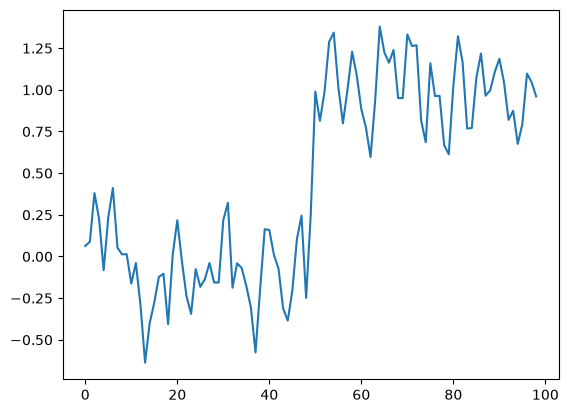

In [3]:
# source-cells: 8
# Take the mean of neighboring pixels
smooth_signal = (noisy_signal[:-1] + noisy_signal[1:])/2.0 #(0,1),(1,2),...(98,99)
fig, ax = plt.subplots()
ax.plot(smooth_signal);
plt.show()

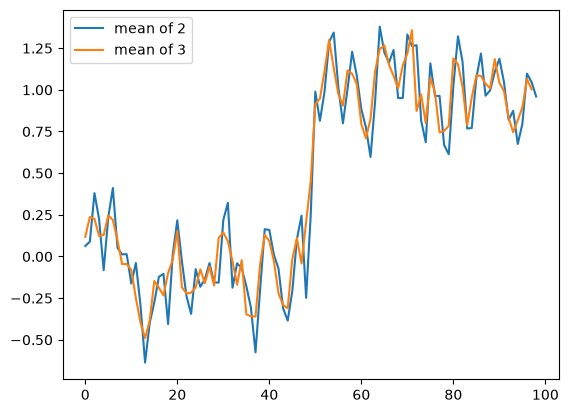

In [4]:
# source-cells: 9
# What happens if we want to take the three neighboring pixels? We can do the same thing:
smooth_signal3 = (noisy_signal[:-2] + noisy_signal[1:-1]
                  + noisy_signal[2:])/3  #(0,1,2),(1,2,3),...(97,98,99)
fig, ax = plt.subplots()
ax.plot(smooth_signal, label='mean of 2')
ax.plot(smooth_signal3, label='mean of 3')
ax.legend(loc='upper left');
plt.show()

source-cells: 10
### 用卷積表示鄰域平均

三點平均等於對每個完整視窗乘上 $[1/3,1/3,1/3]$ 後加總：

$$m[i]=\frac{x[i]+x[i+1]+x[i+2]}3,\quad i=0,\ldots,N-3.$$

因此 `valid` 結果長度為 $N-2$。本例兩點、三點平均分別有99、98個輸出，不是與原訊號等長。下面先驗證手算和卷積相同，再用動畫逐步查看kernel覆蓋的樣本。

smooth_signal3 and smooth_signal32 are equal: True


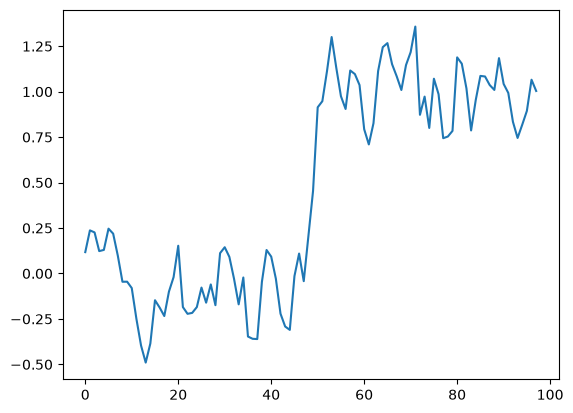

In [5]:
# source-cells: 11
# Same as above, using a convolution kernel
# Neighboring pixels multiplied by 1/3 and summed
mean_kernel3 = np.full((3,), 1/3)
smooth_signal32 = np.convolve(noisy_signal, mean_kernel3, mode='valid')
fig, ax = plt.subplots()
ax.plot(smooth_signal32)

print('smooth_signal3 and smooth_signal32 are equal:', np.allclose(smooth_signal3, smooth_signal32))
plt.show()

In [6]:
# source-cells: 12
# Static 3-point convolution is plotted above; the 11-point plot follows.
mean_kernel11 = np.full((11,), 1/11)
lab('convolution1d', signal=noisy_signal, kernels={'3-point': mean_kernel3, '11-point': mean_kernel11})

source-cells: 13
### 換成十一點平均

十一點kernel讓更多鄰近樣本一起平均，平滑更明顯，步階也變得較寬。這次仍使用valid，只有完整落在輸入內的90個視窗會產生輸出。

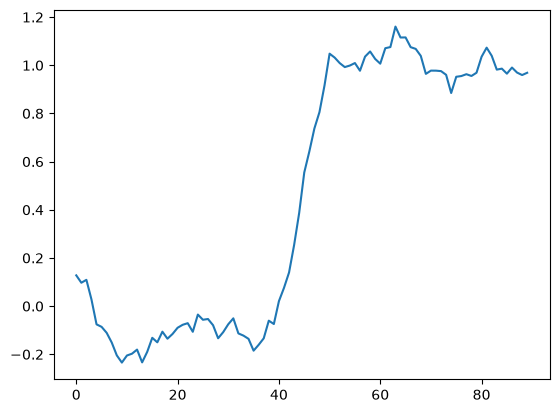

In [7]:
# source-cells: 13
# The advantage of convolution is that it's just as easy to take the average of 11 points as 3:
mean_kernel11 = np.full((11,), 1/11)
smooth_signal11 = np.convolve(noisy_signal, mean_kernel11, mode='valid')
fig, ax = plt.subplots()
ax.plot(smooth_signal11);
plt.show()

source-cells: 14-16
(filtering)=

### 邊界：valid 與 same

valid不補邊界，所以三點、十一點核分別留下98、90個輸出。此例kernel短於輸入，same在兩端補零並保留100個輸出；邊界視窗混入補上的零，數值會受到影響。以下保留原圖比較，再直接核對三點same的第一個與最後一個值。

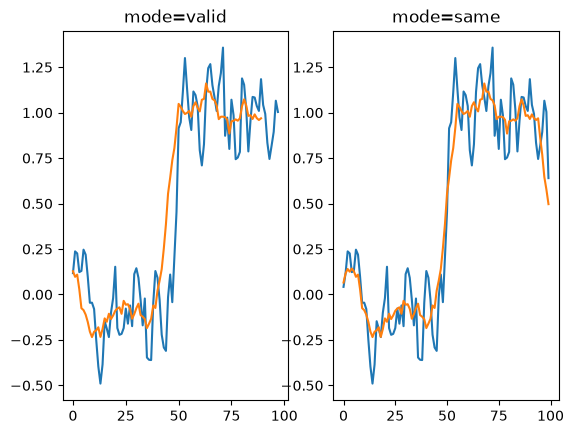

In [8]:
# source-cells: 14
# You can use mode='same' to pad the edges of the array with zero and compute a result of the same size as the input:
smooth_signal3same = np.convolve(noisy_signal, mean_kernel3, mode='same')
smooth_signal11same = np.convolve(noisy_signal, mean_kernel11, mode='same')

fig, ax = plt.subplots(1, 2)
ax[0].plot(smooth_signal32)
ax[0].plot(smooth_signal11)
ax[0].set_title('mode=valid')
ax[1].plot(smooth_signal3same)
ax[1].plot(smooth_signal11same)
ax[1].set_title('mode=same');
plt.show()

In [9]:
# source-cells: 15
print(np.isclose((0+noisy_signal[0]+noisy_signal[1])/3, smooth_signal3same[0]))

True


In [10]:
# source-cells: 16
print(np.isclose((noisy_signal[-2]+noisy_signal[-1]+0)/3, smooth_signal3same[-1]))

True


source-cells: 17
## 二維影像的局部濾波

source-cells: 18
將一維視窗換成二維鄰域。先看7×7影像中央的3×3亮方塊。

[[0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 1. 1. 0. 0.]
 [0. 0. 1. 1. 1. 0. 0.]
 [0. 0. 1. 1. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]]


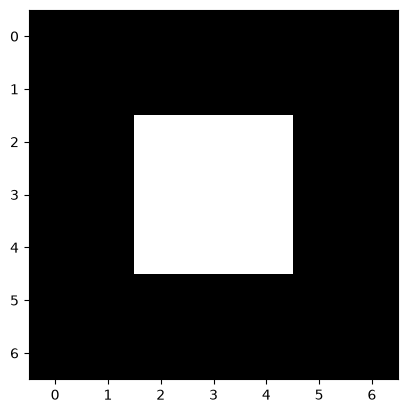

In [11]:
# source-cells: 19
bright_square = np.zeros((7, 7), dtype=float)
bright_square[2:5, 2:5] = 1
print(bright_square)
fig, ax = plt.subplots()
ax.imshow(bright_square);
plt.show()

source-cells: 20
### 平均濾波器

source-cells: 21
3×3平均核對九個像素給相同權重。視窗跨過亮方塊邊界時，亮暗像素會混在一起。以下保留靜態原圖、逐像素視窗及完整輸出，也提供可播放的掃描動畫。邊界採零補值，仍除以9。

In [12]:
# source-cells: 22
mean_kernel = np.full((3, 3), 1/9)

print(mean_kernel)

[[0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]]


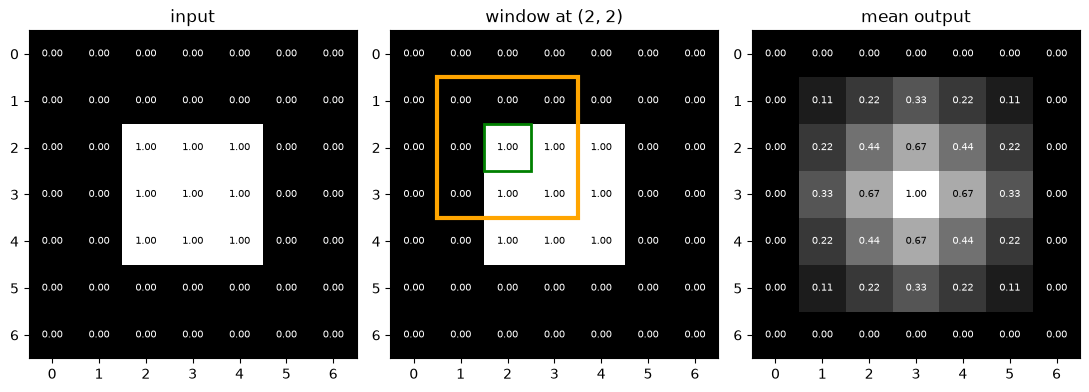

In [13]:
# source-cells: 23
mean_square = ndi.convolve(bright_square, mean_kernel, mode='constant', cval=0)
fig, axes = plt.subplots(1, 3, figsize=(11, 4))
for ax, values, title in zip(axes, [bright_square, bright_square, mean_square],
                            ['input', 'window at (2, 2)', 'mean output']):
    ax.imshow(values, vmin=0, vmax=1)
    ax.set_title(title)
    for (r, c), value in np.ndenumerate(values):
        ax.text(c, r, f'{value:.2f}', ha='center', va='center', fontsize=7,
                color='black' if value > .5 else 'white')
axes[1].add_patch(patches.Rectangle((.5, .5), 3, 3, fill=False, edgecolor='orange', linewidth=3))
axes[1].add_patch(patches.Rectangle((1.5, 1.5), 1, 1, fill=False, edgecolor='green', linewidth=2))
plt.tight_layout()
plt.show()
lab('convolution2d', image=bright_square, kernel=mean_kernel)

source-cells: 24
```{dropdown} 固定 kernel 與 CNN
CNN也會計算局部加權和，但kernel由資料學得，通常還搭配多個通道、非線性函數與多層運算。本例則固定平均核，只示範局部加權；不能把整個CNN視為只有這一次平均。
```

source-cells: 25
## 基礎濾波器

source-cells: 26
改變鄰域的權重或計算方式，就能得到不同的平滑與邊緣響應。先比較Gaussian和平均濾波，再看差分與中位數。

source-cells: 27
### Gaussian filter

source-cells: 28
Gaussian filter讓越靠近中心的像素占較大權重，和平均濾波一樣會平滑影像，也會改變邊界。下例標準差固定為1。Rank mean使用整數影像，程式明確轉成uint8，再將結果以浮點強度比較。

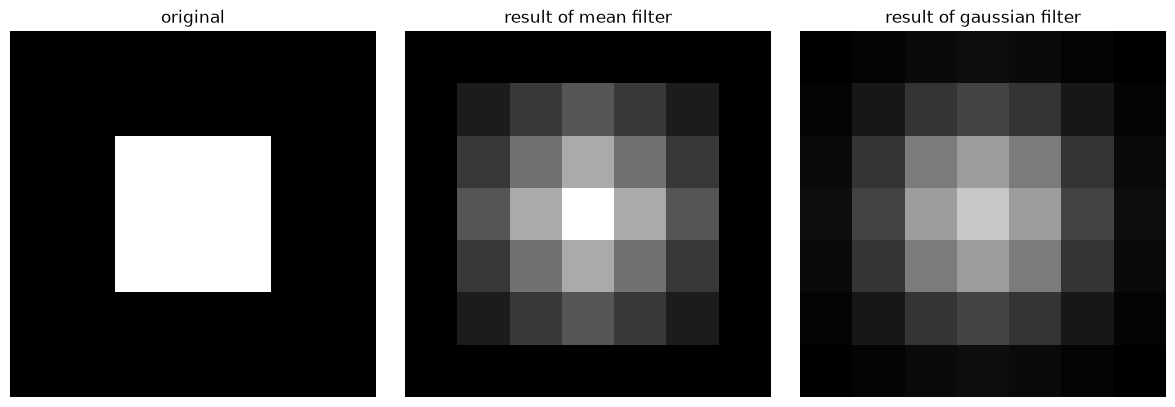

In [14]:
# source-cells: 29
bright_square_uint8 = ski.util.img_as_ubyte(bright_square)
smooth_mean = ski.filters.rank.mean(bright_square_uint8, np.ones((3, 3), dtype=np.uint8))
sigma = 1
smooth = ski.filters.gaussian(ski.util.img_as_float(bright_square_uint8), sigma)
imshow_all(bright_square_uint8, smooth_mean, smooth,
           titles=['original', 'result of mean filter', 'result of gaussian filter'])

plt.show()

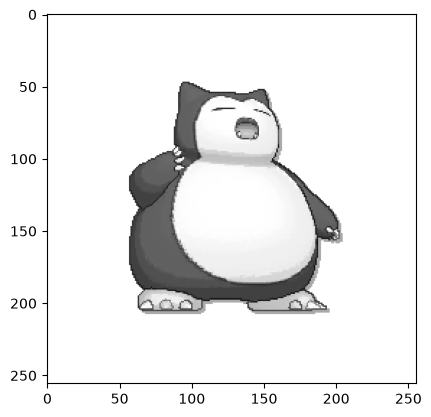

In [15]:
# source-cells: 30
snorlax = ski.io.imread(image_path('snorlax.png'))
img_rgb = ski.color.rgba2rgb(snorlax)
gray = ski.color.rgb2gray(img_rgb)
plt.imshow(gray, cmap='gray')

plt.show()

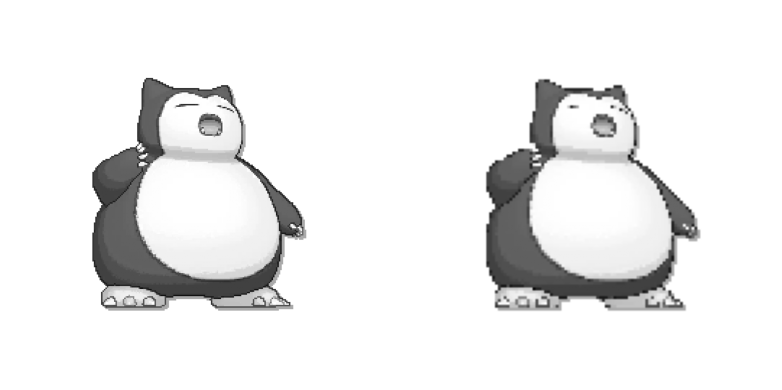

In [16]:
# source-cells: 31
# Create lower reolution image
pixelated = gray[::2, ::2]
imshow_all(gray, pixelated)
plt.show()

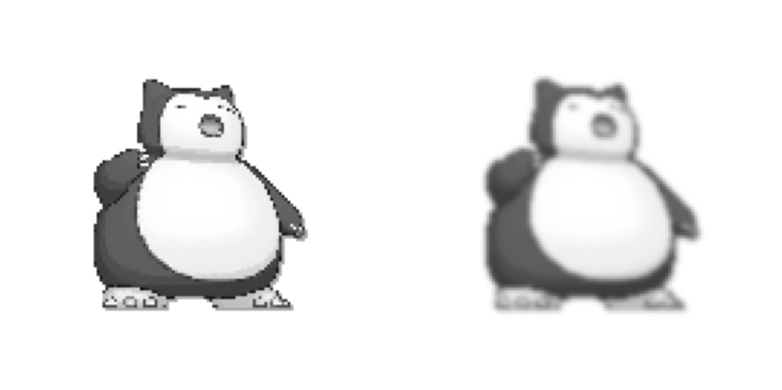

In [17]:
# source-cells: 32
# The Gaussian filter returns a float image, regardless of input.
# Cast to float so the images have comparable intensity ranges.
pixelated_float = ski.util.img_as_float(pixelated)
smooth = ski.filters.gaussian(pixelated_float, sigma=1)
imshow_all(pixelated_float, smooth)
plt.show()

source-cells: 33
## 基礎邊緣濾波

source-cells: 34
邊緣是亮度快速改變的位置。前面的Snorlax先由RGBA合成RGB、轉灰階，再每兩個像素取一個，最後平滑；接著用同一張像素化影像觀察邊界。直接間隔取樣沒有預先anti-aliasing，事後平滑無法消除已經發生的aliasing。

source-cells: 35
### 差分濾波器

source-cells: 36
垂直排列的 $[-1,0,1]^{\mathsf T}$ 比較下方與上方像素，近似沿列方向的導數。本例使用correlation，所以符號是下方減上方；若改成convolution，同一kernel會翻轉，差分的正負號也會相反。平均核對稱，所以前面的平均卷積沒有這個差異。

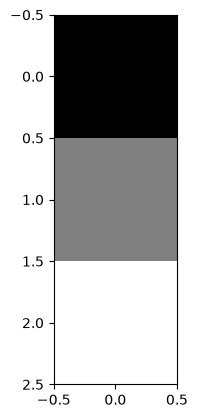

In [18]:
# source-cells: 37
vertical_kernel = np.array([
    [-1],
    [ 0],
    [ 1],
])
plt.imshow(vertical_kernel, cmap='gray');
plt.show()

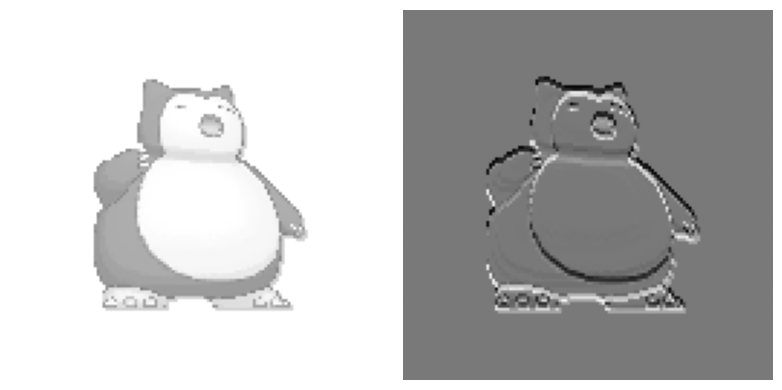

In [19]:
# source-cells: 38
# We should use correlate to meet our convention
# https://medium.com/@aybukeyalcinerr/correlation-vs-convolution-filtering-2711d8bb3666
#gradient_vertical = ndi.convolve(pixelated.astype(float), vertical_kernel)
gradient_vertical = ndi.correlate(pixelated_float, vertical_kernel)
imshow_all(pixelated, gradient_vertical)
plt.show()

source-cells: 39
### Sobel 邊緣濾波器

source-cells: 40
Sobel在一個方向估計差分，同時沿另一方向做少量平滑，再合併兩個方向的梯度大小。先做Gaussian smoothing能降低雜訊造成的零碎響應，也會使邊界變寬。

下面保留原本平滑前後的比較，右圖乘1.8只是顯示倍率，不表示平滑後梯度變大。Kernel設計可讀 [Sobel中文介紹](https://medium.com/@allen73/%E5%BF%83%E5%BE%97-edge-detection-%E8%88%87-sobel-operator-%E7%B0%A1%E4%BB%8B-bd69204e1352) 與 [Sobel設計討論](https://stackoverflow.com/questions/17078131/why-sobel-operator-looks-that-way)。

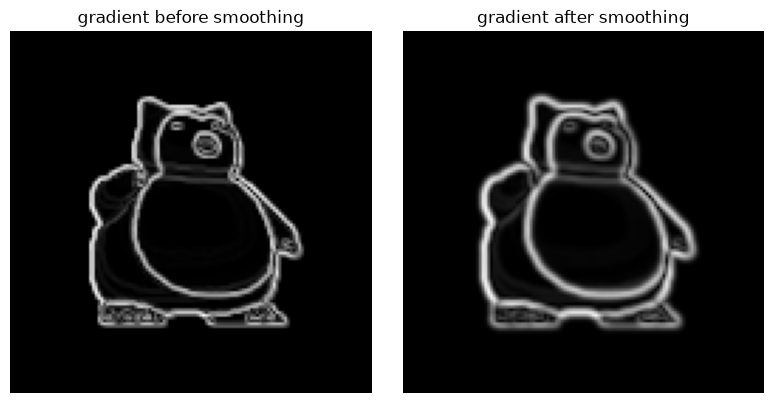

In [20]:
# source-cells: 41
pixelated_gradient = ski.filters.sobel(pixelated)
gradient = ski.filters.sobel(smooth)
titles = ['gradient before smoothing', 'gradient after smoothing']
# Scale smoothed gradient up so they're of comparable brightness.
imshow_all(pixelated_gradient, gradient*1.8, titles=titles)
plt.show()

source-cells: 42
比較輪廓的連續性與寬度。平滑後的邊緣通常較連續，也可能失去較細的轉折。

source-cells: 43
局部運算不一定是線性加權。接下來用中位數取代鄰域平均，看看能否減少極端像素的影響，同時保留較分明的亮暗邊界。什麼應當算成雜訊，仍要依影像與任務判斷。

source-cells: 44
### Median filter

source-cells: 45
Median filter回傳鄰域中位數。在亮暗兩側分明的邊界，中位數較不容易產生平均後的中間灰階；少量極端值也較不會拉動結果。不過它仍可能刪掉細線或改變小物件，並非所有邊緣都能完整保留。先對Snorlax使用disk(1)，再對coins使用disk(10)，比較平均與中位數。

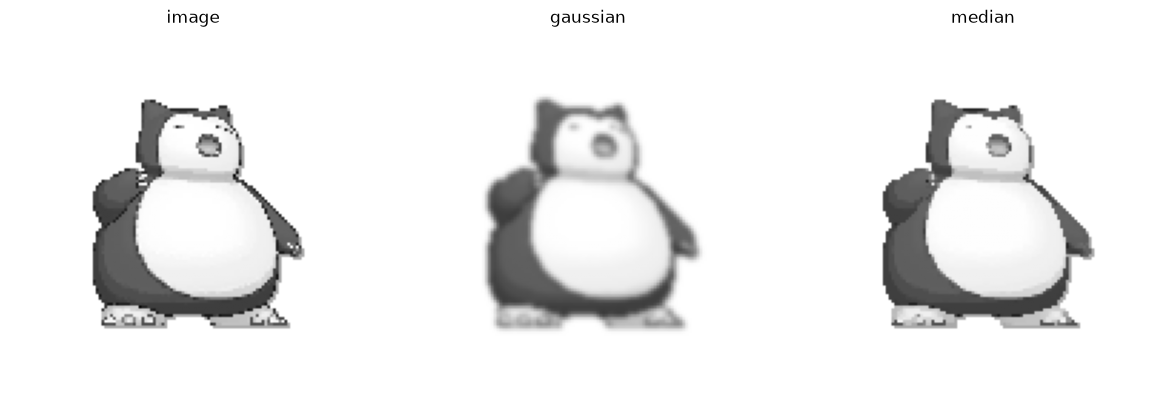

In [21]:
# source-cells: 46
neighborhood = ski.morphology.disk(radius=1)  # "selem" is often the name used for "structuring element"
median = ski.filters.rank.median(ski.util.img_as_ubyte(pixelated), neighborhood)
titles = ['image', 'gaussian', 'median']
imshow_all(pixelated, smooth, median, titles=titles)
plt.show()

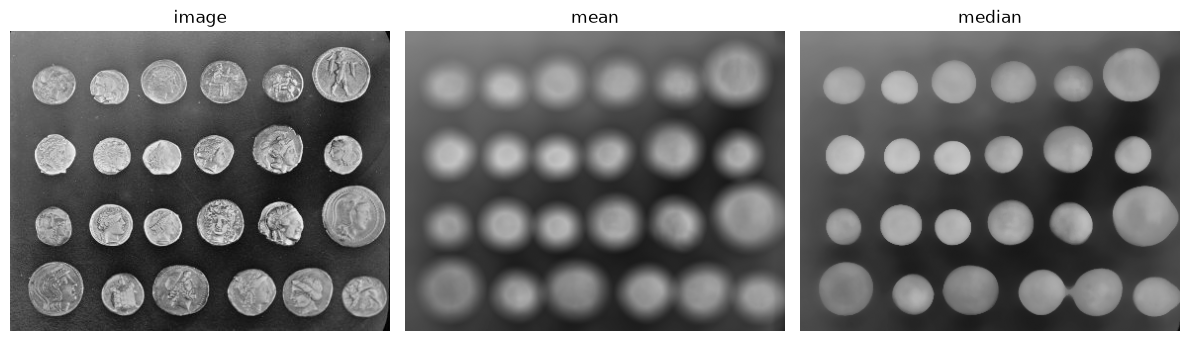

In [22]:
# source-cells: 47
neighborhood = ski.morphology.disk(10)
coins = ski.data.coins()
mean_coin = ski.filters.rank.mean(coins, neighborhood)
median_coin = ski.filters.rank.median(coins, neighborhood)
titles = ['image', 'mean', 'median']
imshow_all(coins, mean_coin, median_coin, titles=titles)
plt.show()

source-cells: 48
較大的圓盤讓平均後的硬幣邊緣模糊；中位數保留較明確的亮暗轉換，但邊界與局部紋理也會改變。

source-cells: 49
更多kernel互動範例可見：[https://setosa.io/ev/image-kernels/](https://setosa.io/ev/image-kernels/)，以及 [https://generic-github-user.github.io/Image-Convolution-Playground/src/](https://generic-github-user.github.io/Image-Convolution-Playground/src/)

source-cells: 50
## 形態學運算

source-cells: 51
形態學用鄰域的形狀處理影像。灰階侵蝕取局部最小值，灰階膨脹取最大值；二值影像以1表示前景時，分別對應縮小與擴張前景。

定義與API可查 [OpenCV morphology](https://docs.opencv.org/3.4/d9/d61/tutorial_py_morphological_ops.html)、[scikit-image morphology](https://scikit-image.org/docs/stable/api/skimage.morphology.html) 與 [SciPy morphology](https://docs.scipy.org/doc/scipy/reference/ndimage.html#morphology)。

In [23]:
# source-cells: 52
# plt.rcParams['image.cmap'] = 'cubehelix'
plt.rcParams['image.interpolation'] = 'none'
plt.show()

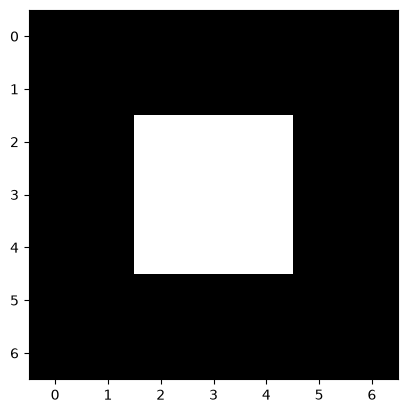

In [24]:
# source-cells: 53
image = np.array([[0, 0, 0, 0, 0, 0, 0],
                  [0, 0, 0, 0, 0, 0, 0],
                  [0, 0, 1, 1, 1, 0, 0],
                  [0, 0, 1, 1, 1, 0, 0],
                  [0, 0, 1, 1, 1, 0, 0],
                  [0, 0, 0, 0, 0, 0, 0],
                  [0, 0, 0, 0, 0, 0, 0]], dtype=np.uint8)
plt.imshow(image);
plt.show()

source-cells: 54
結構元素中的非零位置指定參與運算的鄰居。保留原本3×3方形、半徑3菱形與半徑30圓盤。菱形按 $|\Delta r|+|\Delta c|\leq3$ 選鄰居，因此也包含 $(1,1)$ 這種對角偏移；半徑1的菱形才是上下左右的十字。

目前API用 `footprint_rectangle((3,3))` 取代 `square(3)`，尺寸與形狀不變。

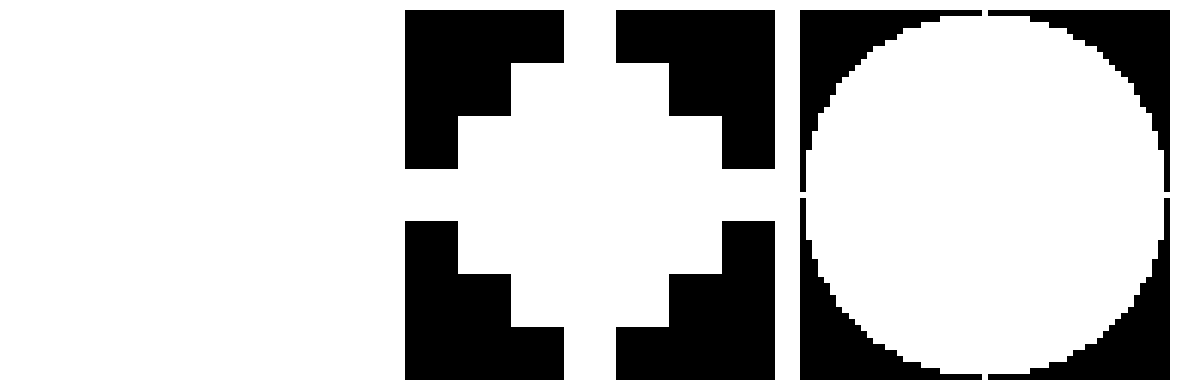

In [25]:
# source-cells: 55
sq = ski.morphology.footprint_rectangle((3, 3))
dia = ski.morphology.diamond(radius=3)
disk = ski.morphology.disk(radius=30)
imshow_all(sq, dia, disk)
plt.show()

source-cells: 56
### 侵蝕

source-cells: 57
Kernel滑過影像時，只有被覆蓋的像素全部為1，中心才留下1。因此主物件縮小，比kernel小的亮點可能消失，狹窄連接也可能斷開。

source-cells: 58
Footprint中心對應目前輸出位置；其中的1表示納入鄰域，0表示忽略。先用3×3方形侵蝕亮方塊。

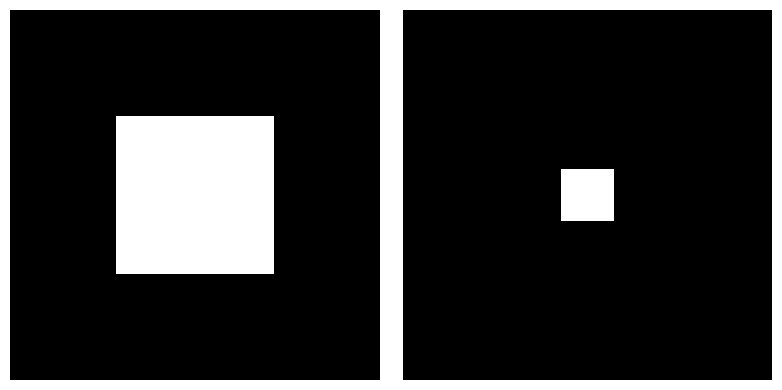

In [26]:
# source-cells: 59
imshow_all(image, ski.morphology.erosion(image, sq))
plt.show()

source-cells: 60
### 膨脹

source-cells: 61
只要鄰域有一個1，中心就設為1。先使用3×3方形，再換半徑3的菱形，比較擴張範圍與新邊界的形狀。

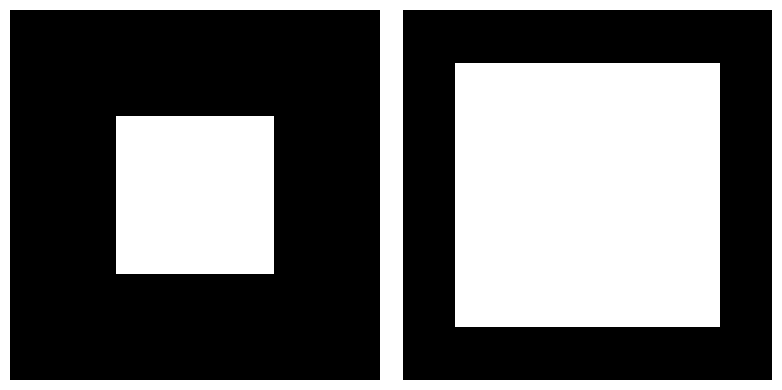

In [27]:
# source-cells: 62
imshow_all(image, ski.morphology.dilation(image, sq))
plt.show()

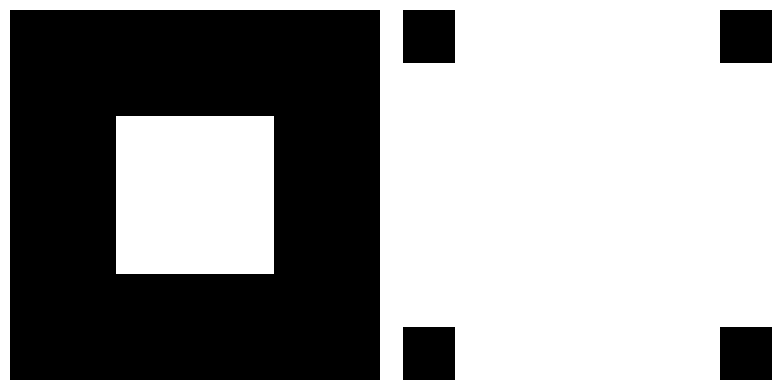

In [28]:
# source-cells: 63
imshow_all(image, ski.morphology.dilation(image, dia))
plt.show()

source-cells: 64
### 開運算

source-cells: 65
開運算先侵蝕、再膨脹。侵蝕移除小亮點後，膨脹只擴張剩下的區域，不會找回已完全消失的亮點。

source-cells: 66
以下小矩陣同時包含主物件、孤立亮點與暗缺口。依序看原圖、侵蝕與開運算。

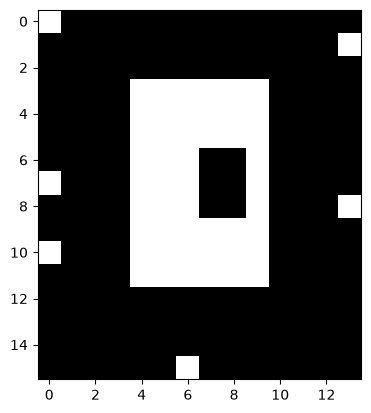

In [29]:
# source-cells: 67
image = np.array([[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
				  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                  [0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0],
                  [0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0],
                  [0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0],
                  [0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0],
                  [1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0],
                  [0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1],
                  [0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0],
                  [1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0],
                  [0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0],
                  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
				  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                  [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0]], np.uint8)
plt.imshow(image);
plt.show()

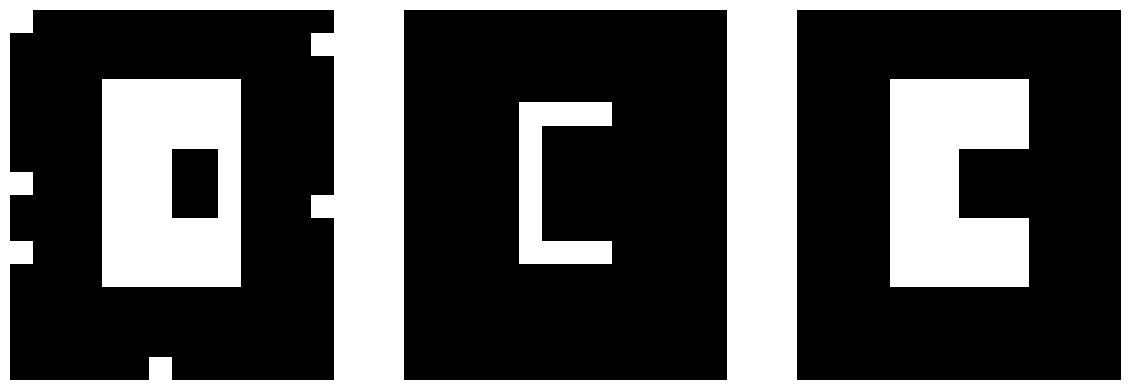

In [30]:
# source-cells: 68
imshow_all(image, ski.morphology.erosion(image, sq), ski.morphology.opening(image, sq)) # erosion -> dilation
plt.show()

source-cells: 69
### 閉運算

source-cells: 70
閉運算先膨脹、再侵蝕，可以填平比footprint小的暗缺口或接合窄縫。順序與開運算相反，效果也不同。

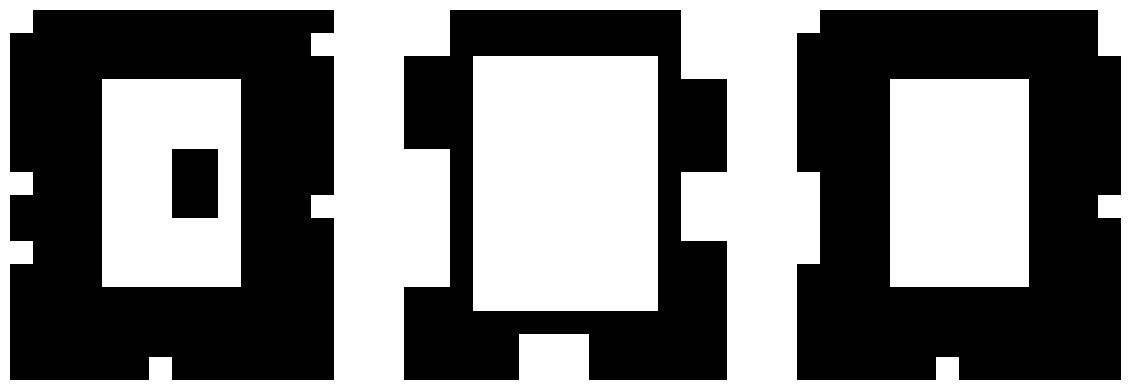

In [31]:
# source-cells: 71
imshow_all(image, ski.morphology.dilation(image, sq), ski.morphology.closing(image, sq)) # dilation -> erosion
plt.show()

source-cells: 72
### 先閉運算，再開運算

先修補小缺口，再移除小亮點。觀察內部孔洞、主物件輪廓與孤立像素如何變化；形態學處理的是指定尺度的形狀，不會自行判斷什麼才是真實物件。

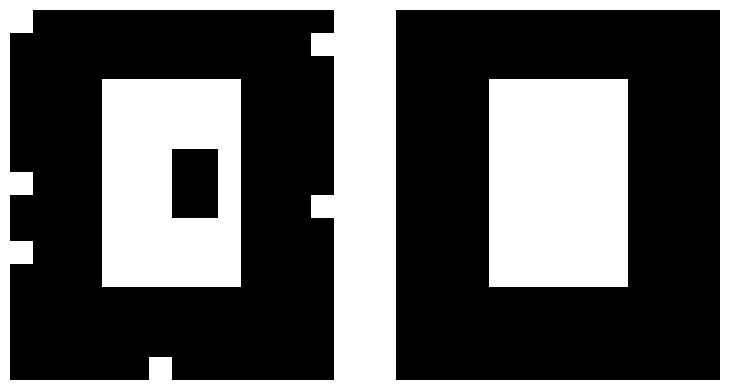

In [32]:
# source-cells: 73
imshow_all(image, ski.morphology.opening(ski.morphology.closing(image, sq), sq))
plt.show()

source-cells: 74
## 影像分割

source-cells: 75
分割API與方法索引：[https://scikit-image.org/docs/stable/api/skimage.segmentation.html](https://scikit-image.org/docs/stable/api/skimage.segmentation.html)

source-cells: 76
### 全域閾值：硬幣與背景

source-cells: 77
全域閾值讓每個像素和同一個數比較，再指定前景或背景。先看coins的灰階直方圖，再比較閾值100與150：較低閾值保留更多硬幣，也可能混入背景；較高閾值則會漏掉硬幣內部的暗區。這裡尚未為每一枚硬幣編號。

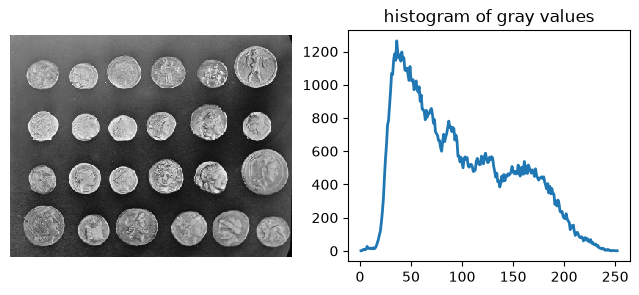

In [33]:
# source-cells: 78
coins = ski.data.coins()
hist, hist_centers = ski.exposure.histogram(coins)

fig, axes = plt.subplots(1, 2, figsize=(8, 3))
axes[0].imshow(coins, cmap=plt.cm.gray)
axes[0].axis('off')
axes[1].plot(hist_centers, hist, lw=2)
axes[1].set_title('histogram of gray values');
plt.show()

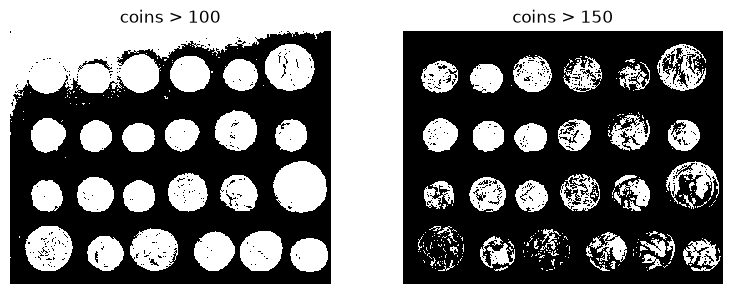

In [34]:
# source-cells: 79
fig, axes = plt.subplots(1, 2, figsize=(8, 3), sharey=True)

axes[0].imshow(coins > 100, cmap=plt.cm.gray)
axes[0].set_title('coins > 100')

axes[1].imshow(coins > 150, cmap=plt.cm.gray)
axes[1].set_title('coins > 150')

for a in axes:
    a.axis('off')

plt.tight_layout()
plt.show()

source-cells: 80
結果是二值影像；白色代表通過目前規則的像素，不保證每一區都是完整硬幣。

source-cells: 81
### 掃描文字：固定、Yen 與 Sauvola 閾值

紙張的亮度不均。先看page原圖及直方圖，再用固定閾值100選出暗文字。

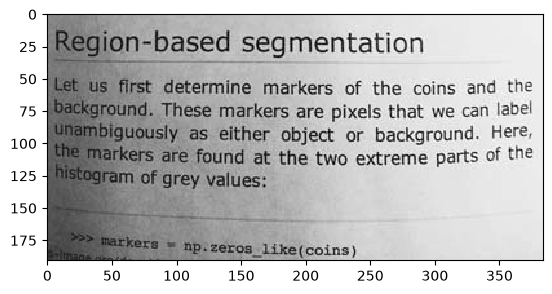

In [35]:
# source-cells: 82
text = ski.data.page()

plt.imshow(text, cmap='gray');
plt.show()

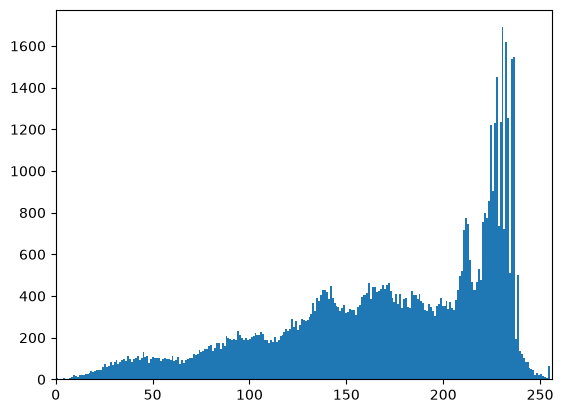

In [36]:
# source-cells: 83
fig, ax = plt.subplots(1, 1)
ax.hist(text.ravel(), bins=256, range=[0, 255])
ax.set_xlim(0, 256);
plt.show()

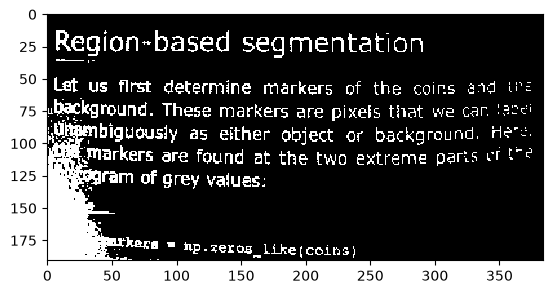

In [37]:
# source-cells: 84
text_segmented = text < 100

plt.imshow(text_segmented, cmap='gray');
plt.show()

source-cells: 85
陰影使單一全域閾值難以兼顧整頁。自動方法可從資料估計閾值，但不一定能處理空間上變化的背景。

source-cells: 86
Yen根據全域直方圖選一個數，仍是全域方法。Sauvola利用局部平均與標準差，為不同位置產生不同閾值。兩者都不需標註，但局部方法仍有視窗等參數，不能把自動方法理解成完全無設定。

121


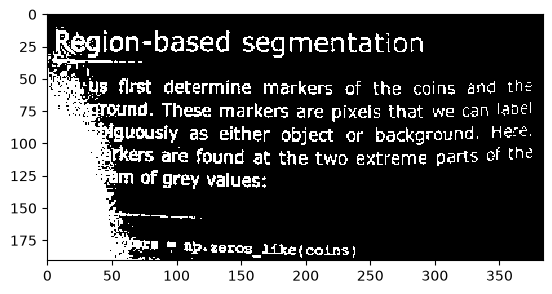

In [38]:
# source-cells: 87
text_threshold = ski.filters.threshold_yen(text)
print(text_threshold)
plt.imshow(text < text_threshold, cmap='gray');
plt.show()

source-cells: 88
[原稿的thresholding guide](https://scikit-image.org/docs/0.25.x/auto_examples/applications/plot_thresholding_guide.html) 比較全域與局部方法，可將輸出是一個數或一張閾值圖作為辨認起點。

(191, 384)


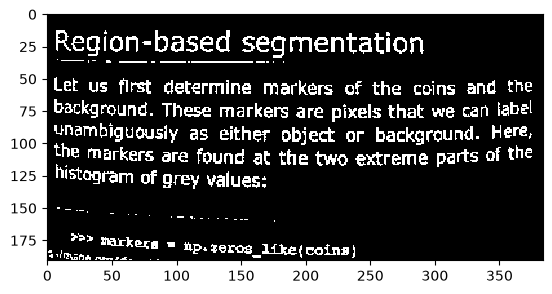

In [39]:
# source-cells: 89
text_threshold = ski.filters.threshold_sauvola(text)
print(text_threshold.shape)
plt.imshow(text < text_threshold, cmap='gray');
plt.show()

source-cells: 90
### 背景估計與 black tophat

source-cells: 91
除了調整閾值，也可以先移除不均勻的背景。文字比周圍紙張暗，且筆畫比背景變化細，因此用31×31矩形做灰階閉運算，填掉暗筆畫，近似紙張背景。

灰階膨脹取最大值，使亮區向暗筆畫擴張，再由侵蝕修回較大的亮度輪廓。Black tophat取閉運算減原圖，使暗文字在結果中變亮；white tophat取原圖減開運算，用來凸顯暗背景上的亮物件。

$$B_{\mathrm{black}}=\operatorname{closing}(I)-I,\qquad B_{\mathrm{white}}=I-\operatorname{opening}(I).$$

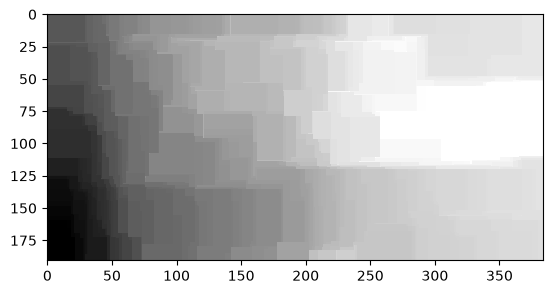

In [40]:
# source-cells: 92
# Lets start with a tiny filter, defined by the footprint argument, and work our way up.
# We're using rectangle filters because they are much faster.

plt.imshow(ski.morphology.closing(text, footprint=ski.morphology.footprint_rectangle((31,31))), cmap='gray');
plt.show()

source-cells: 93
先檢查估得的背景是否仍留有文字痕跡，再看black tophat能否凸顯筆畫。

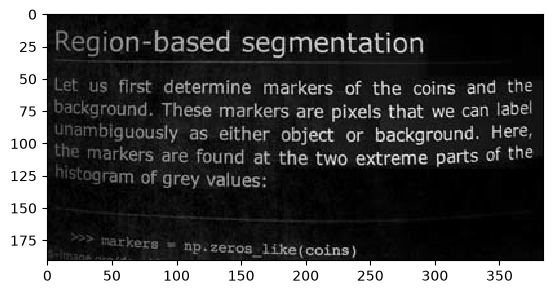

In [41]:
# source-cells: 94
bth = ski.morphology.black_tophat(text, footprint=ski.morphology.footprint_rectangle((31,31)))
plt.imshow(bth, cmap='gray');
plt.show()

source-cells: 95
文字強度仍可能隨位置不同，但緩慢變動的背景已減少。接著比較各種自動閾值法。

skimage.filters.thresholding.threshold_isodata
skimage.filters.thresholding.threshold_li
skimage.filters.thresholding.threshold_mean
skimage.filters.thresholding.threshold_minimum
skimage.filters.thresholding.threshold_otsu
skimage.filters.thresholding.threshold_triangle
skimage.filters.thresholding.threshold_yen


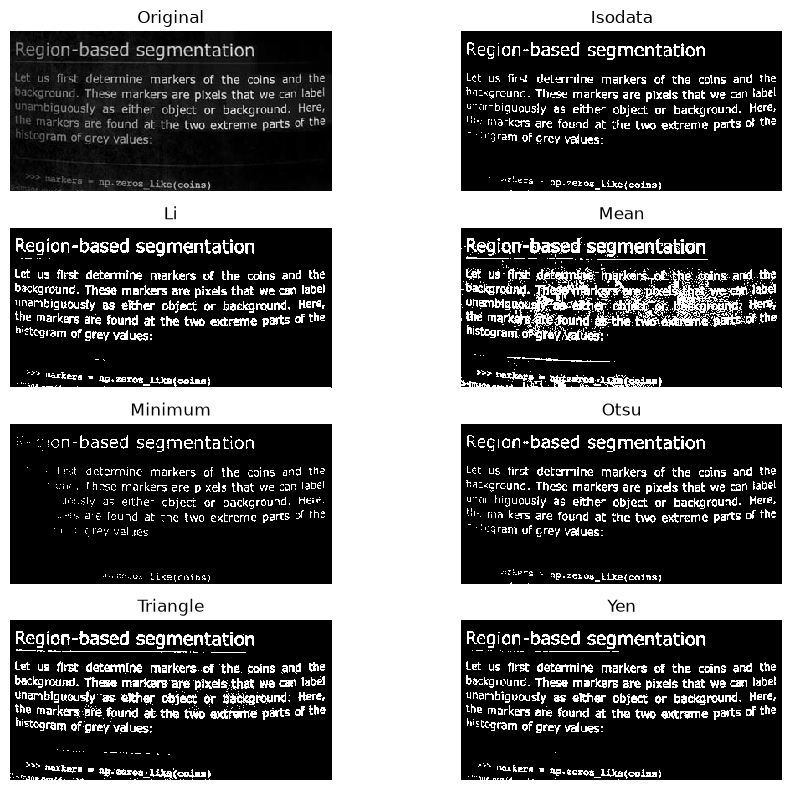

In [42]:
# source-cells: 96
fig, ax = ski.filters.try_all_threshold(bth, figsize=(10, 8), verbose=True)
plt.show();
plt.show()

source-cells: 97
```{dropdown} 如何調整背景估計的 footprint？
鄰域要大到能跨過文字，卻不能大到抹平背景本身的變化。長寬比例可依前景形狀與背景變化方向調整，亮度漸層本身不足以決定要用高矩形或寬矩形。比較估得的背景、tophat與二值結果，才能判斷尺寸是否合適。
```

原稿的 [tophat notebook](https://github.com/scikit-image/skimage-tutorials/blob/main/lectures/5_tophat_filters.ipynb) 可接著閱讀背景估計與尺寸選擇。

source-cells: 98
### 從邊緣到區域：Canny

source-cells: 99
Canny先平滑影像，計算梯度，再沿梯度方向做非極大值抑制，讓邊緣變細。雙閾值把候選分成強、弱兩組；強邊緣留下，弱邊緣只有連到強邊緣時才保留，稱為hysteresis tracking。

先對Snorlax使用sigma=1.0，比較原圖、平滑後Sobel（顯示乘1.8）與Canny，再看coins預設Canny。讀法可對照 [官方Canny範例](https://scikit-image.org/docs/stable/auto_examples/edges/plot_canny.html) 與 [原稿CS131作業範例](https://github.com/Hugstar/Solutions-Stanford-cs131-Computer-Vision-Foundations-and-Application/blob/master/hw2_release/hw2.ipynb)。

In [43]:
# source-cells: 100
print('pixelated shape:', pixelated.shape)

pixelated shape: (128, 128)


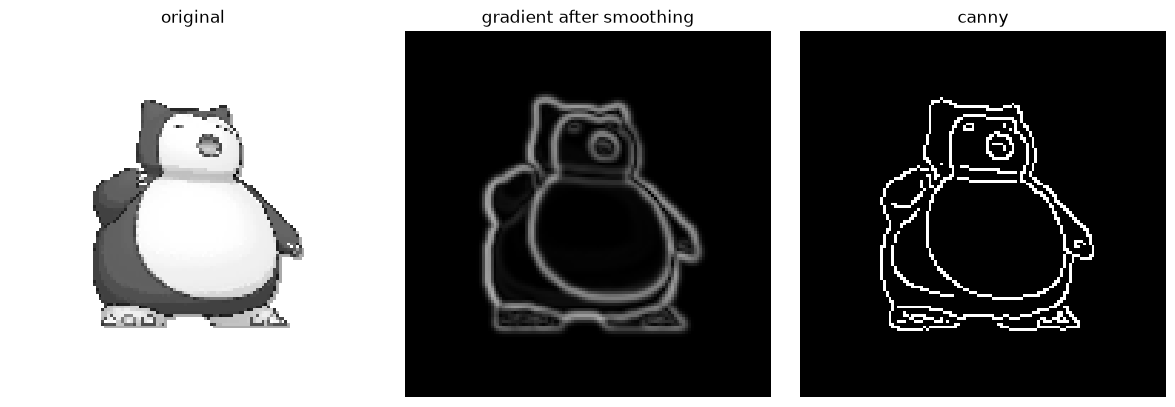

In [44]:
# source-cells: 101
edges = ski.feature.canny(pixelated, sigma=1.0, low_threshold=None, high_threshold=None)
gradient = ski.filters.sobel(smooth)
titles = ['original', 'gradient after smoothing', 'canny']
# Scale smoothed gradient up so they're of comparable brightness.
imshow_all(pixelated, gradient*1.8, edges, titles=titles)
plt.show()

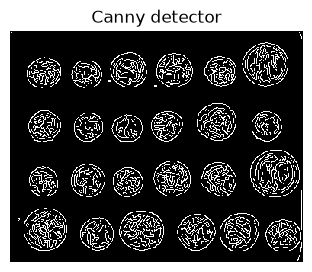

In [45]:
# source-cells: 102
edges = ski.feature.canny(coins)

fig, ax = plt.subplots(figsize=(4, 3))
ax.imshow(edges, cmap=plt.cm.gray)
ax.set_title('Canny detector')
ax.axis('off');
plt.show()

source-cells: 103
`binary_fill_holes` 填的是不與影像外部連通的背景孔洞。膨脹會擴張前景；填孔洞則依背景是否能連到外部決定哪些位置填滿，兩者的操作不同。

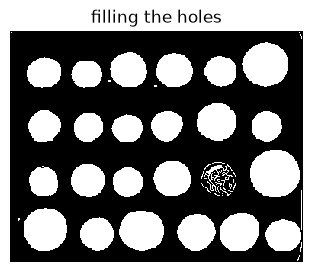

In [46]:
# source-cells: 104
fill_coins = ndi.binary_fill_holes(edges)
#sq = ski.morphology.disk(4)
#fill_coins = ski.morphology.binary_dilation(edges, sq)


fig, ax = plt.subplots(figsize=(4, 3))
ax.imshow(fill_coins, cmap=plt.cm.gray)
ax.set_title('filling the holes')
ax.axis('off');
plt.show()

source-cells: 105
移除面積小於21 pixels的連通前景，可清掉小碎片。這個規則不會修補未封閉的硬幣輪廓。

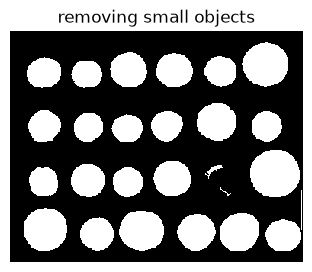

In [47]:
# source-cells: 106
min_area = 21
# Original min_size=21 means area <21; current max_size is inclusive.
coins_cleaned = ski.morphology.remove_small_objects(fill_coins, max_size=min_area - 1)
fig, ax = plt.subplots(figsize=(4, 3))
ax.imshow(coins_cleaned, cmap=plt.cm.gray)
ax.set_title('removing small objects')
ax.axis('off')

plt.show()

source-cells: 107
保留這個失敗結果：若邊緣有缺口，硬幣內部仍和外部背景連通，就無法填滿。小物件清理也不能補回缺口，因此接下來改用區域與markers。

source-cells: 108
### 以區域擴張：Watershed

source-cells: 109
[Watershed](https://scikit-image.org/docs/stable/auto_examples/segmentation/plot_watershed.html) 使用地形圖與markers。下面保留原講義的地形示意；硬幣例子則以Sobel梯度當作地形高度。

```{figure} images/original_notebooks/ch02-cell109-1.png
:name: fig-ch02-original-watershed
:width: 90%
:alt: 原講義地形示意，對照谷地、集水區與分水嶺。

由markers向低處擴張，區域相遇後形成分界。
```

source-cells: 110
Watershed從標記開始擴張，優先經過地形較低的位置。用梯度當地形時，物件內部較平坦、邊緣較高。地形與markers共同決定分割結果；只有地形而沒有合適markers，仍可能產生不需要的細碎區域。

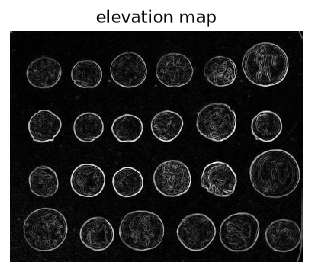

In [48]:
# source-cells: 111
elevation_map = ski.filters.sobel(coins)

fig, ax = plt.subplots(figsize=(4, 3))
ax.imshow(elevation_map, cmap=plt.cm.gray)
ax.set_title('elevation map')
ax.axis('off');
plt.show()

source-cells: 112
依直方圖兩端選取比較確定的像素：`coins < 30`指定label 1（背景），`coins > 150`指定label 2（亮硬幣區域）。0表示尚未指定marker，不是第三類。

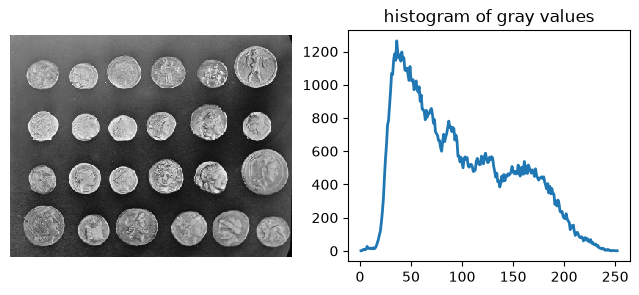

In [49]:
# source-cells: 113
coins = ski.data.coins()
hist, hist_centers = ski.exposure.histogram(coins)

fig, axes = plt.subplots(1, 2, figsize=(8, 3))
axes[0].imshow(coins, cmap=plt.cm.gray)
axes[0].axis('off')
axes[1].plot(hist_centers, hist, lw=2)
axes[1].set_title('histogram of gray values');
plt.show()

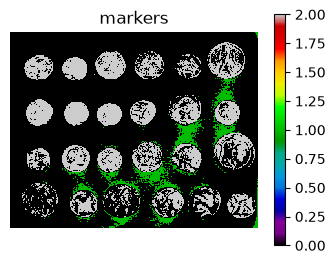

In [50]:
# source-cells: 114
markers = np.zeros_like(coins)
markers[coins < 30] = 1
markers[coins > 150] = 2

fig, ax = plt.subplots(figsize=(4, 3))
im = ax.imshow(markers, cmap=plt.cm.nipy_spectral)
plt.colorbar(im, ax=ax)
ax.set_title('markers')
ax.axis('off');
plt.show()

In [51]:
# source-cells: 115
print('marker values:', np.unique(markers))  # 0 means unmarked

marker values: [0 1 2]


source-cells: 116
從markers填完整張地形後，每個像素得到label 1或2。`regionprops`依label量面積及周長，因此下面有兩筆統計。Label 2即使包含多枚不相連的硬幣，仍合成同一筆；目前沒有逐顆硬幣編號。

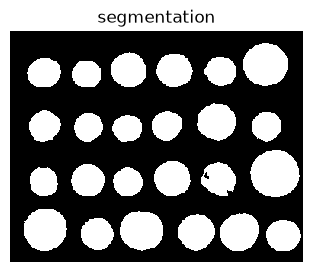

In [52]:
# source-cells: 117
segmentation_coins = ski.segmentation.watershed(elevation_map, markers)

fig, ax = plt.subplots(figsize=(4, 3))
ax.imshow(segmentation_coins, cmap=plt.cm.gray)
ax.set_title('segmentation')
ax.axis('off');
plt.show()

In [53]:
# source-cells: 118
# compute the size and perimeter of the two segmented regions
properties = ski.measure.regionprops(segmentation_coins)
print([prop.area for prop in properties])
print([prop.perimeter for prop in properties])

[np.float64(77442.0), np.float64(38910.0)]
[np.float64(5082.625863363164), np.float64(3577.8613613753473)]


source-cells: 119
分割後可接續閱讀markers與地形選擇：

> [https://github.com/scikit-image/skimage-tutorials/blob/main/lectures/6\_watershed\_tricks.ipynb](https://github.com/scikit-image/skimage-tutorials/blob/main/lectures/6_watershed_tricks.ipynb)

> [https://github.com/scikit-image/skimage-tutorials/tree/main/lectures](https://github.com/scikit-image/skimage-tutorials/tree/main/lectures)

source-cells: 120
## 影像描述子與特徵擷取

source-cells: 121
分割指出像素所屬區域，特徵偵測則找出容易重複辨認的位置或外觀，供物件偵測、拼接與匹配使用。

平坦區域向哪裡移動都差不多；直邊緣沿邊緣移動時也難定位；角點在兩個方向都有變化，通常較容易定位。好的特徵需要有區別力、可重複偵測，對指定範圍的雜訊或變換穩定，也要考慮計算與儲存成本。實際能承受的旋轉、尺度變化與遮擋範圍，仍需依方法與資料檢查。

偵測先找位置，例如Harris、Shi–Tomasi；描述再將附近外觀編成向量，例如SIFT、SURF、ORB。原稿連結的 [OpenCV Understanding Features](https://docs.opencv.org/4.x/df/d54/tutorial_py_features_meaning.html) 用平坦區域、邊緣與角點比較定位能力。

source-cells: 122
### HOG：梯度方向直方圖

source-cells: 123
HOG以固定網格摘要影像的梯度。先計算水平、垂直梯度，再將影像分成cells；像素依梯度大小向對應的方向bin投票。將cells組成block正規化後，最後展平成特徵向量。部分方法會先做gamma壓縮，本例沿用原設定，不額外啟用。

保留原本 **8 bins、每cell為8×8 pixels、每block為1×1 cell**。因此這裡只在單一cell內正規化，沒有跨相鄰cells。右圖顯示局部梯度方向，`fd`才是供分類器使用的數值向量。

若有 $n_r,n_c$ 個完整cell rows/columns，本例特徵長度為 $8n_rn_c$。

```{dropdown} 與2×2 block比較
一般 $b_r\times b_c$ cells的block，特徵長度為 $(n_r-b_r+1)(n_c-b_c+1)b_rb_cK$。2×2 block共同正規化相鄰四個cells，且相鄰blocks重疊；這是另一組參數設定，不是本例1×1 block的行為。
```

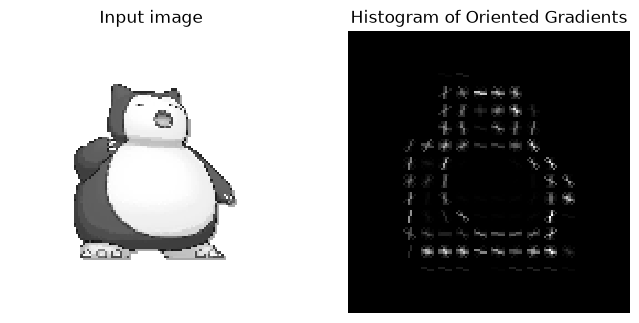

In [54]:
# source-cells: 124
fd, hog_image = ski.feature.hog(pixelated, orientations=8, pixels_per_cell=(8, 8),
                    cells_per_block=(1, 1), visualize=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4), sharex=True, sharey=True)

ax1.axis('off')
ax1.imshow(pixelated, cmap=plt.cm.gray)
ax1.set_title('Input image')

# Rescale histogram for better display
hog_image_rescaled = ski.exposure.rescale_intensity(hog_image, in_range=(0, 10))

ax2.axis('off')
ax2.imshow(hog_image_rescaled, cmap=plt.cm.gray)
ax2.set_title('Histogram of Oriented Gradients')
plt.show()
plt.show()

In [55]:
# source-cells: 125
print('image and descriptor shapes:', pixelated.shape, fd.shape)
print('expected HOG size:', 8 * (pixelated.shape[0]//8) * (pixelated.shape[1]//8))

image and descriptor shapes: (128, 128) (2048,)
expected HOG size: 2048


source-cells: 126
[HOG／SVM中文說明](https://medium.com/curiosity-and-exploration/hog-svm-c2fb01304c0) 可接著看描述子如何交給分類器；注意比較文中的block設定與本例的1×1。

source-cells: 127
更多描述子可對照API與作業範例：

> [https://scikit-image.org/docs/stable/api/skimage.feature.html](https://scikit-image.org/docs/stable/api/skimage.feature.html)

> [https://github.com/mikucy/CS131/blob/master/hw3\_release/hw3.ipynb](https://github.com/mikucy/CS131/blob/master/hw3_release/hw3.ipynb)

source-cells: 128
## 可訓練式分割：局部特徵與隨機森林

source-cells: 129
固定閾值只看亮度，可訓練式分割則能同時利用局部亮度、邊緣及紋理。先標註少量前景、背景或其他類別，計算每個像素的多尺度局部特徵，再用random forest學習特徵與標籤的關係，預測未標註像素。

它有標註提供監督資訊，與前面的自動閾值不同。應在未參與訓練的影像或區域檢查結果，避免把記住訓練紋理誤當成能處理新資料。原稿的 [trainable segmentation範例](https://scikit-image.org/docs/stable/auto_examples/segmentation/plot_trainable_segmentation.html#sphx-glr-auto-examples-segmentation-plot-trainable-segmentation-py) 示範特徵、標註與分類器的搭配。

source-cells: 130
## 三維影像分析

source-cells: 131
三維影像是切片堆疊，鄰域、分割與區域量測也要增加一個維度。圓盤可改成球形鄰域，面積改成體積；切片間距與平面像素大小可能不同，相同格數不一定代表相同物理長度。

閱讀原稿指定的 [Data Umbrella notebook](https://github.com/scikit-image/skimage-tutorials/blob/main/workshops/2022-data-umbrella/2022_10-skimage_data_umbrella.ipynb) 時，先看軸順序、voxel spacing與視覺化，再對照分割標籤及區域量測。

source-cells: 132
## 延伸閱讀與參考資料

source-cells: 133
- **Szeliski，Computer Vision: Algorithms and Applications**：依原稿第3.2–3.3節讀濾波及局部運算、第7.1–7.2與7.5節讀特徵、匹配與追蹤；使用不同版本時先核對目錄。也可搭配Forsyth／Ponce與Howse／Minichino的影像處理說明 {cite}`szeliski2022,forsyth2012,howse2020`。
- **OpenCV影像處理與特徵**：[image processing](https://docs.opencv.org/4.x/d2/d96/tutorial_py_table_of_contents_imgproc.html)、[feature2d](https://docs.opencv.org/4.x/db/d27/tutorial_py_table_of_contents_feature2d.html)。按濾波、形態學、特徵的次序查API與範例。
- **完整課程**：[scikit-image tutorials](https://github.com/scikit-image/skimage-tutorials)、[Stanford CS131 Fall 2021](http://vision.stanford.edu/teaching/cs131_fall2021/)。前者可接續本章分割案例，後者補足特徵與電腦視覺背景。下一章再從頻率觀點看影像與濾波。